---
title: "Classify sonar echoes: TabPFN 3 vs 3.5"
description: "Compare TabPFN 3 and 3.5 at classifying sonar echoes from metal cylinders and rocks."
cookbookTags:
  - classification
authors:
  - name: Eliott Kalfon
    linkedin: https://www.linkedin.com/in/eliott-kalfon/
---

A sonar return is an acoustic clue to what lies underwater: a rock or a metal object can produce different patterns of reflected energy. Here we predict whether an echo comes from a metal cylinder or a rock using 60 energy measurements. Distinguishing the two is a small example of the object recognition needed to interpret underwater surveys.

## Setup

Install the dependencies in a fresh Python kernel. Compare TabPFN 3 and 3.5 with standard inference and high thinking effort. Timings include network and queue latency. Set `thinking_metric="log_loss"` so thinking optimizes the same metric shown in the results.

Authenticate using the [quickstart](https://docs.priorlabs.ai/cookbook/quickstart), or set `TABPFN_TOKEN` in your local environment before running the notebook.

In [ ]:
%pip install -q --upgrade tabpfn-client "pandas==2.3.3" "numpy==2.4.6" "scikit-learn==1.9.0" "matplotlib==3.11.1"

In [1]:
import time
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tabpfn_client import TabPFNClassifier
from tabpfn_client.api_models import ModelVersion
from tabpfn_client.models import ApiMode

VERSIONS = {"TabPFN 3": ModelVersion.V3, "TabPFN 3.5": ModelVersion.V3_5}
VARIANTS = [(name, thinking) for name in VERSIONS for thinking in (False, True)]
plt.rcParams.update({"figure.figsize": (7, 3.5), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 120})

def archive(url):
    return ZipFile(BytesIO(urlopen(url).read()))

The helpers below keep model settings and chart colors consistent across variants.

In [2]:
def model_for(cls, name, thinking=False, **kwargs):
    return cls.create_default_for_version(
        VERSIONS[name], n_estimators=4, random_state=42,
        api_mode=ApiMode.ASYNC if thinking else ApiMode.AUTO,
        thinking_effort="high" if thinking else None,
        thinking_metric="log_loss" if thinking else None, **kwargs,
    )

def performance_bars(results, metric, direction):
    colors = {"TabPFN 3": "#90a4ae", "TabPFN 3 + thinking high": "#5c6bc0",
              "TabPFN 3.5": "#80cbc4", "TabPFN 3.5 + thinking high": "#00897b",
              "XGBoost": "#bcaaa4"}
    values = results[metric].iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(values.index, values, color=[colors[name] for name in values.index])
    ax.set(xlabel=f"{metric} ({direction} is better)", ylabel="")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    low, high = values.min(), values.max()
    if low > 0 and high - low < 0.2 * high:
        padding = max((high - low) * 0.3, high * 0.01, 0.001)
        ax.set_xlim(max(0, low - padding), high + 2 * padding)
        ax.set_title("Zoomed axis (does not start at zero)", fontsize=9)
    else:
        ax.set_xlim(0, high * 1.22)
    fig.tight_layout()
    plt.show()


## Data and split

[UCI Sonar](https://archive.ics.uci.edu/dataset/151/connectionist+bench+sonar+mines+vs+rocks) contains 208 echoes with 60 energy measurements each. `M` denotes a metal cylinder and `R` a rock. Keep all 60 features and use a fixed stratified split: 124 training, 42 validation, and 42 test rows.

In [3]:
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split

with archive("https://archive.ics.uci.edu/static/public/151/connectionist+bench+sonar+mines+vs+rocks.zip") as z:
    member = next(name for name in z.namelist() if name.endswith("sonar.all-data"))
    data = pd.read_csv(z.open(member), header=None).drop_duplicates()

X = data.iloc[:, :-1].to_numpy()
y = (data.iloc[:, -1].to_numpy() == "M").astype(int)
train_valid, test = train_test_split(
    np.arange(len(y)), test_size=0.2, stratify=y, random_state=42
)
train, valid = train_test_split(
    train_valid, test_size=0.25, stratify=y[train_valid], random_state=42
)
assert X.shape == (208, 60)
assert not (set(train) & set(valid) | set(train) & set(test) | set(valid) & set(test))
print(f"Train / validation / test: {len(train)} / {len(valid)} / {len(test)}")

Train / validation / test: 124 / 42 / 42


## Compare on held-out echoes

Fit all four variants on the combined 166 training and validation rows, then evaluate the same 42 test echoes. **Log-loss** measures probability quality; lower is better. Thinking explicitly optimizes this metric.

Each row is an echo. This split does not establish generalization to new physical objects or recording conditions.

In [4]:
X_train, X_test = X[train_valid], X[test]
y_train, y_test = y[train_valid], y[test]

rows, predictions = [], {}
for name, thinking in VARIANTS:
    label = name + (" + thinking high" if thinking else "")
    start = time.perf_counter()
    model = model_for(TabPFNClassifier, name, thinking)
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    predictions[label] = p
    rows.append({"Model": label, "Log-loss": log_loss(y_test, p),
                 "Accuracy": accuracy_score(y_test, p >= 0.5),
                 "Seconds": time.perf_counter() - start})
    print(f"Finished {label}")
all_results = pd.DataFrame(rows).set_index("Model")

Train set already exists, skipping upload.


Test set already exists, skipping upload.


Train set already exists, skipping upload.


Finished TabPFN 3


Test set already exists, skipping upload.


...

Test set already exists, skipping upload.


Train set already exists, skipping upload.


Finished TabPFN 3.5


Test set already exists, skipping upload.


Finished TabPFN 3.5 + thinking high


## Results

TabPFN 3.5 reduces log-loss from 0.2670 to 0.1845 compared with v3, about a 31% reduction. Optimizing log-loss with thinking improves v3 to 0.2090, while v3.5 changes only slightly to 0.1844. The main gain on these 42 held-out echoes comes from the newer model.

In [5]:
display(all_results[["Log-loss"]].round(4))

,Log-loss
Model,
TabPFN 3,0.2670
TabPFN 3 + thinking high,0.2090
TabPFN 3.5,0.1845
TabPFN 3.5 + thinking high,0.1844


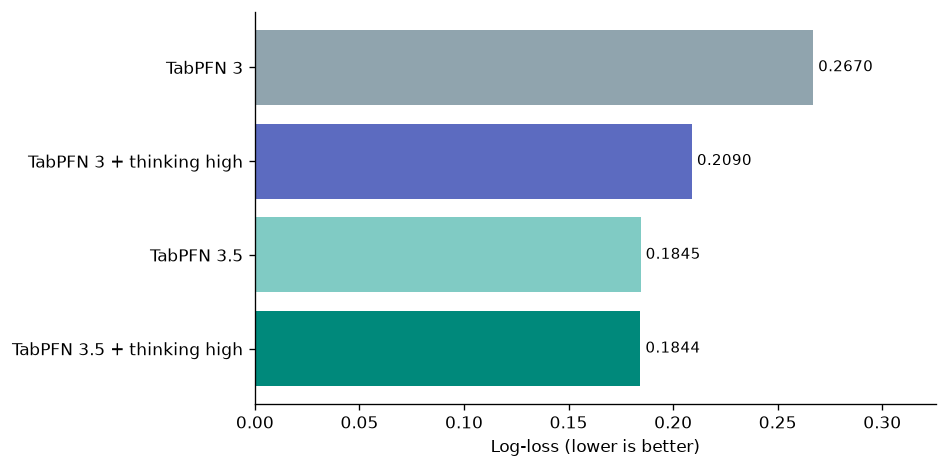

In [6]:
performance_bars(all_results, "Log-loss", "lower")

### What to take away

TabPFN 3.5 gives better probability predictions than v3 in this example, with little additional gain from thinking.